<a href="https://www.kaggle.com/code/omborse771924/most-streamed-artists-on-spotify-eda?scriptVersionId=337702775" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishavsvault/most-streamed-artists-on-spotify/Most Streamed Artists on Spotify (17_07_2026) V1.1.csv
/kaggle/input/datasets/rishavsvault/most-streamed-artists-on-spotify/Most Streamed Artists on Spotify (17_07_2026).csv


## Loading Datase

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rishavsvault/most-streamed-artists-on-spotify/Most Streamed Artists on Spotify (17_07_2026).csv')

In [3]:
df.head()

,Artist,Sex,Country,Langugage,Primary Genre,Artist Type,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions)
0,Drake,Male,Canada,English,Hip-Hop,Solo,137492.1,94851.1,42640.9,53323.9
1,Taylor Swift,Female,United States,English,Pop,Solo,127861.0,126177.3,1683.8,113421.5
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,125899.8,82189.3,43710.5,48887.0
3,The Weeknd,Male,Canada,English,R&B,Solo,95703.2,77189.4,18513.8,51020.0
4,Justin Bieber,Male,Canada,English,Pop,Solo,78104.4,48316.2,29788.2,29638.3


In [4]:
df.tail()

,Artist,Sex,Country,Langugage,Primary Genre,Artist Type,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions)
495,The Cure,Male,United Kingdom,English,Rock,Group,7034.1,7035.0,3.3,6940.1
496,The Marías,Mixed,United States,English,Pop,Group,7029.1,5774.4,1261.4,5705.9
497,Limp Bizkit,Male,United States,English,Nu Metal,Group,7018.9,7018.4,5.4,6806.0
498,Korn,Male,United States,English,Metal,Group,6976.4,4188.4,2798.5,6414.9
499,Omar Courtz,Male,United States,Spanish,Reggaeton,Solo,6972.0,6956.0,20.3,1876.2


In [5]:
df.info

<bound method DataFrame.info of             Artist     Sex         Country Langugage Primary Genre  \
0            Drake    Male          Canada   English       Hip-Hop   
1     Taylor Swift  Female   United States   English           Pop   
2        Bad Bunny    Male   United States   Spanish     Reggaeton   
3       The Weeknd    Male          Canada   English           R&B   
4    Justin Bieber    Male          Canada   English           Pop   
..             ...     ...             ...       ...           ...   
495       The Cure    Male  United Kingdom   English          Rock   
496     The Marías   Mixed   United States   English           Pop   
497    Limp Bizkit    Male   United States   English      Nu Metal   
498           Korn    Male   United States   English         Metal   
499    Omar Courtz    Male   United States   Spanish     Reggaeton   

     Artist Type  Total Streams (in millions)  Lead Streams (in millions)  \
0           Solo                     137492.1     

In [6]:
df.isnull

<bound method DataFrame.isnull of             Artist     Sex         Country Langugage Primary Genre  \
0            Drake    Male          Canada   English       Hip-Hop   
1     Taylor Swift  Female   United States   English           Pop   
2        Bad Bunny    Male   United States   Spanish     Reggaeton   
3       The Weeknd    Male          Canada   English           R&B   
4    Justin Bieber    Male          Canada   English           Pop   
..             ...     ...             ...       ...           ...   
495       The Cure    Male  United Kingdom   English          Rock   
496     The Marías   Mixed   United States   English           Pop   
497    Limp Bizkit    Male   United States   English      Nu Metal   
498           Korn    Male   United States   English         Metal   
499    Omar Courtz    Male   United States   Spanish     Reggaeton   

     Artist Type  Total Streams (in millions)  Lead Streams (in millions)  \
0           Solo                     137492.1   

In [7]:
df.describe

<bound method NDFrame.describe of             Artist     Sex         Country Langugage Primary Genre  \
0            Drake    Male          Canada   English       Hip-Hop   
1     Taylor Swift  Female   United States   English           Pop   
2        Bad Bunny    Male   United States   Spanish     Reggaeton   
3       The Weeknd    Male          Canada   English           R&B   
4    Justin Bieber    Male          Canada   English           Pop   
..             ...     ...             ...       ...           ...   
495       The Cure    Male  United Kingdom   English          Rock   
496     The Marías   Mixed   United States   English           Pop   
497    Limp Bizkit    Male   United States   English      Nu Metal   
498           Korn    Male   United States   English         Metal   
499    Omar Courtz    Male   United States   Spanish     Reggaeton   

     Artist Type  Total Streams (in millions)  Lead Streams (in millions)  \
0           Solo                     137492.1   

In [8]:
df.isnull().sum(
    
)

Artist                            0
Sex                               0
Country                           0
Langugage                         0
Primary Genre                     0
 Artist Type                      0
Total Streams (in millions)       0
Lead Streams (in millions)        3
Feature Streams (in millions)    32
Solo Streams (in millions)        7
dtype: int64

In [9]:
cols = [
    'Lead Streams (in millions)',
    'Feature Streams (in millions)',
    'Solo Streams (in millions)'
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.isnull().sum()

Artist                           0
Sex                              0
Country                          0
Langugage                        0
Primary Genre                    0
 Artist Type                     0
Total Streams (in millions)      0
Lead Streams (in millions)       0
Feature Streams (in millions)    0
Solo Streams (in millions)       0
dtype: int64

In [11]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Artist', 'Sex', 'Country', 'Langugage', 'Primary Genre',
       ' Artist Type', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)'],
      dtype='object')

## EDA

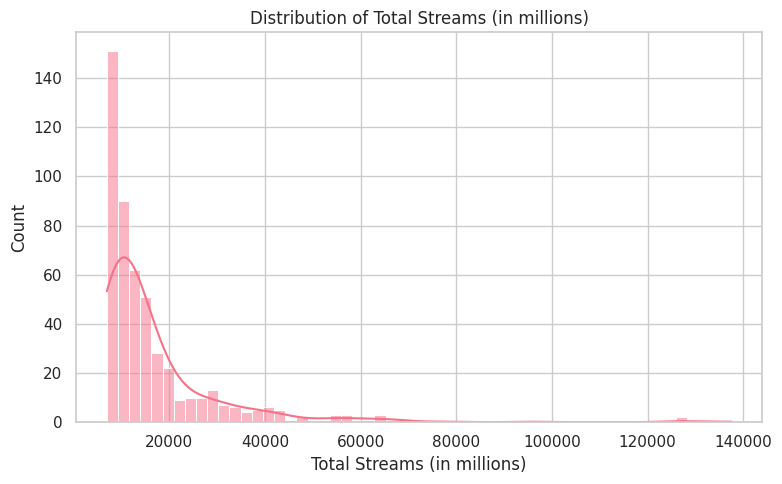

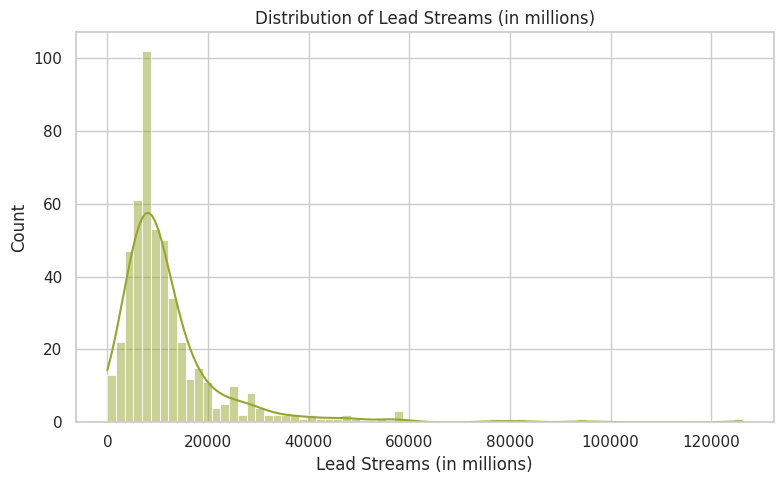

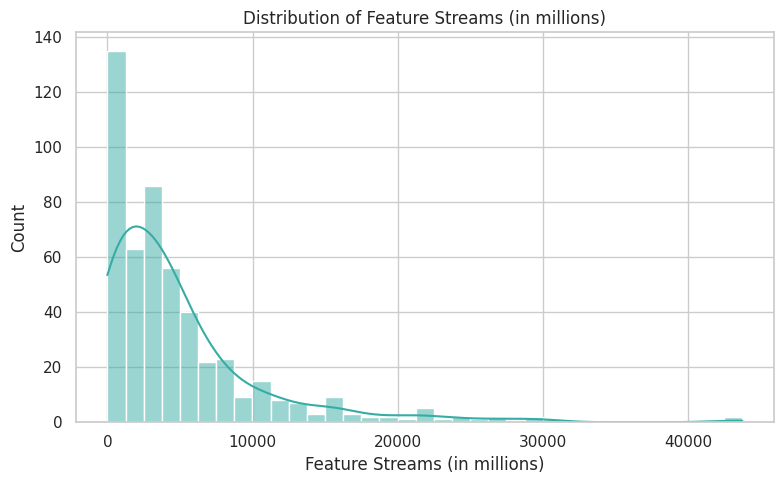

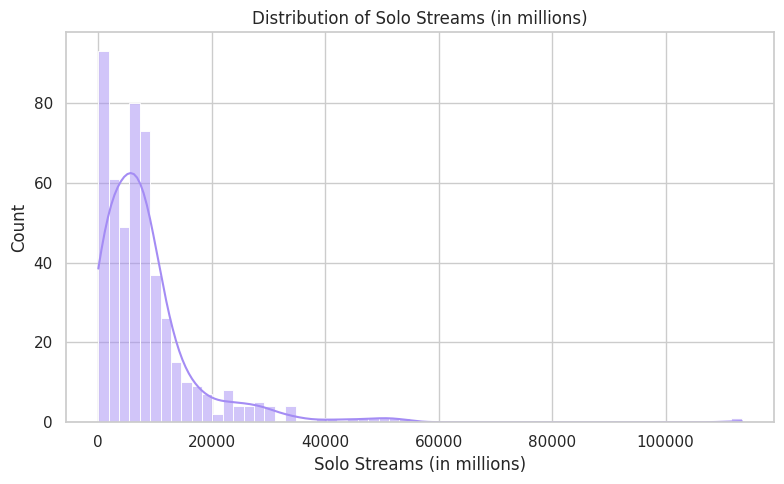

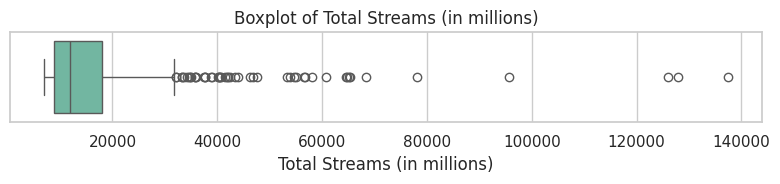

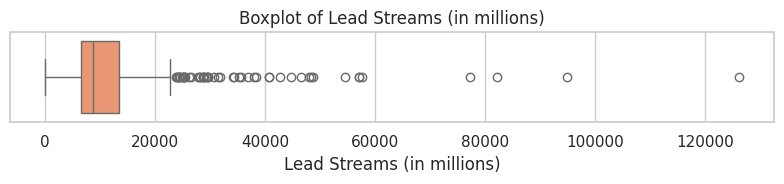

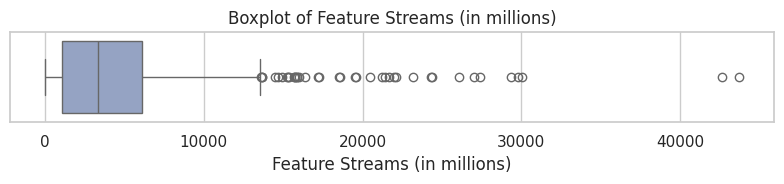

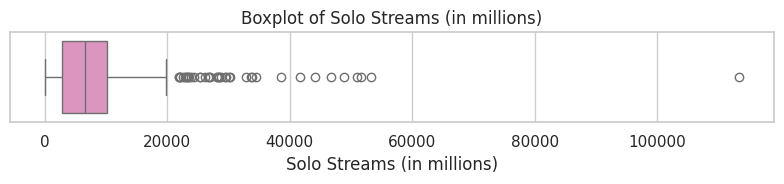

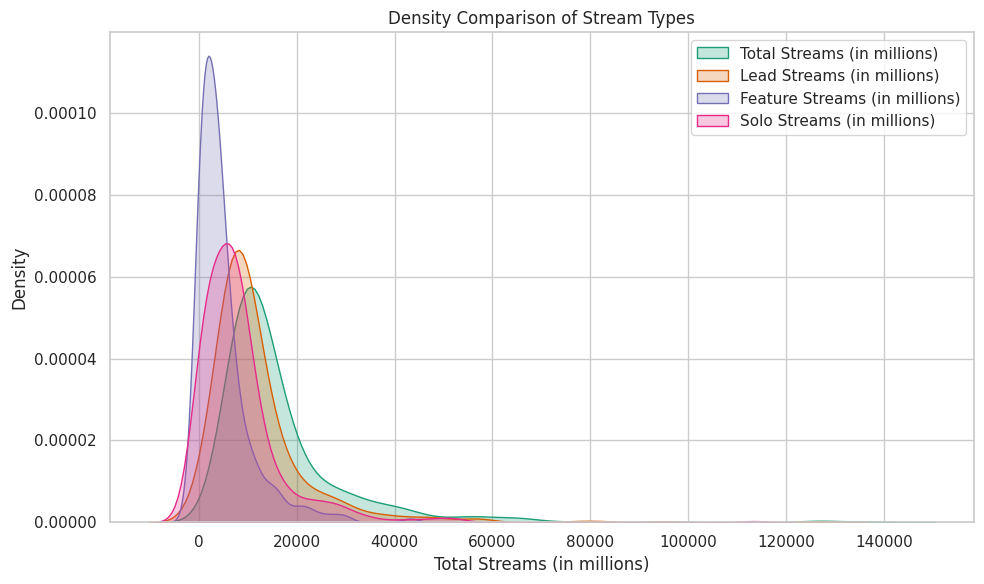

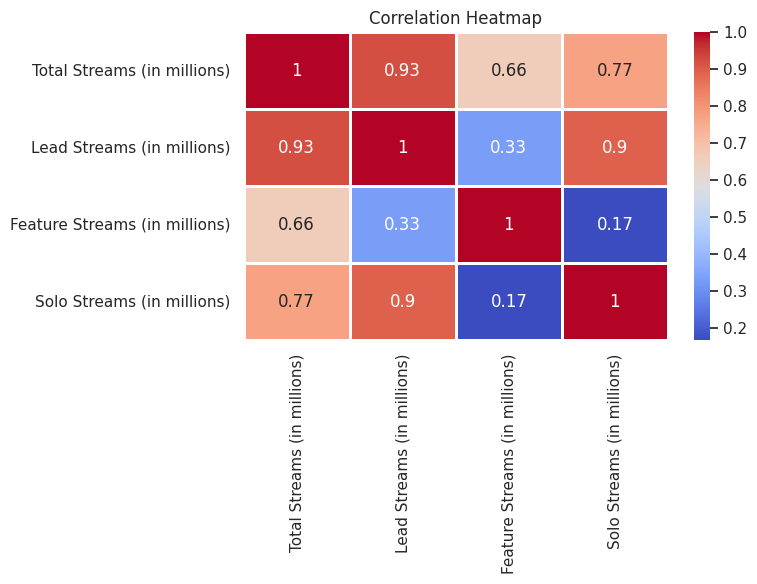

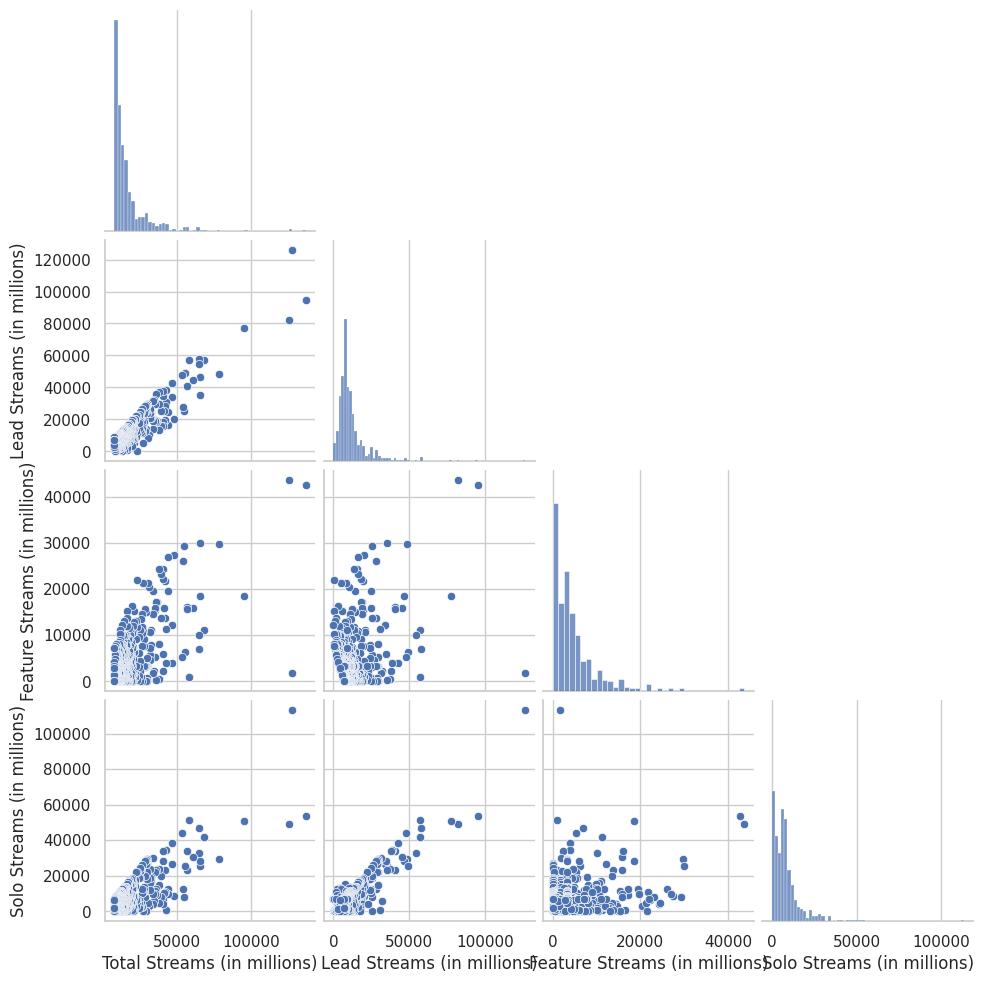

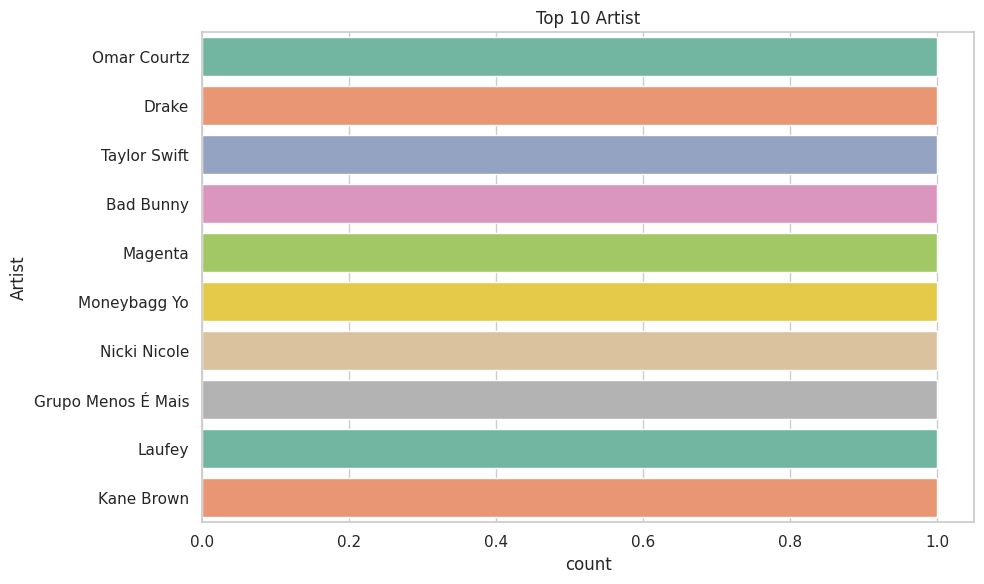

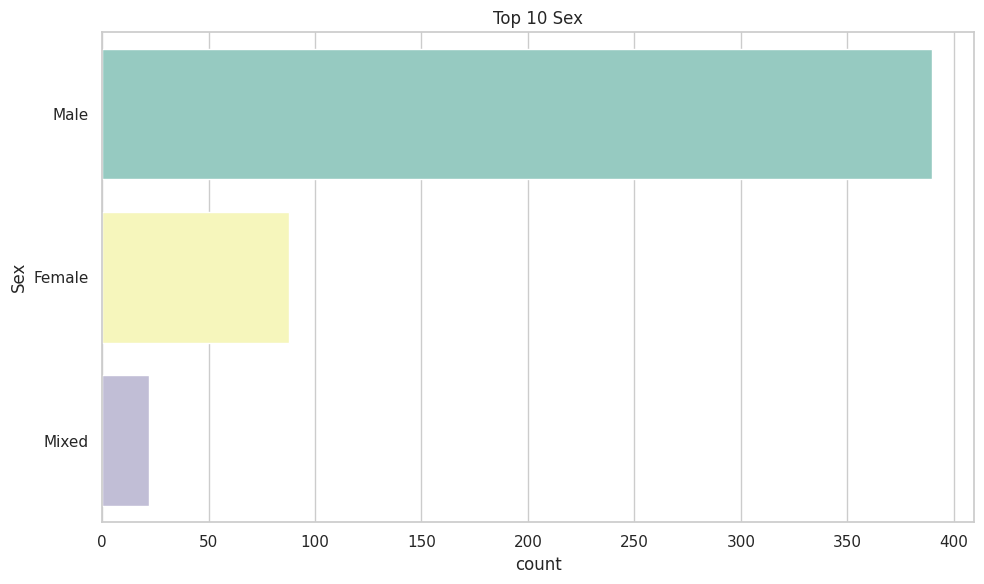

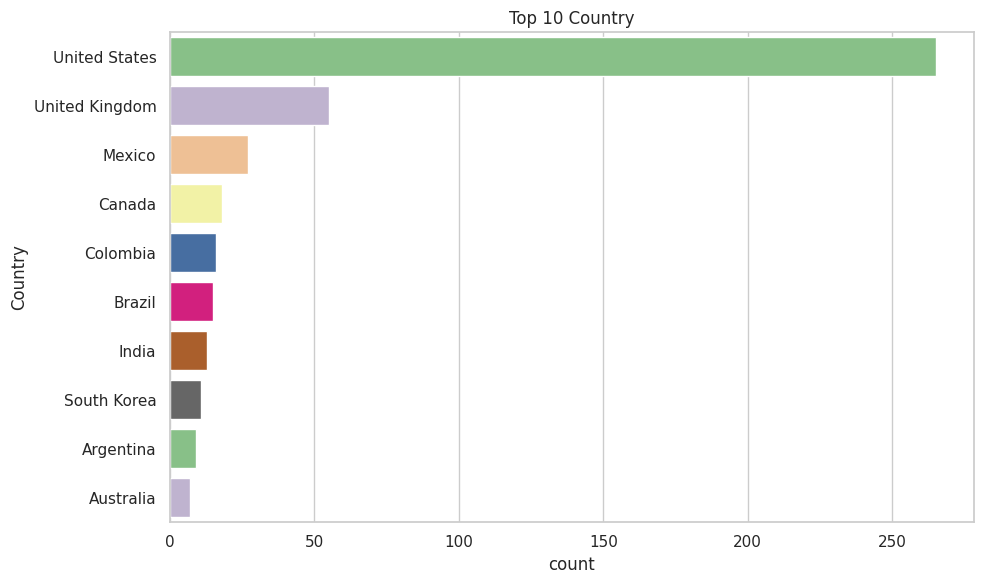

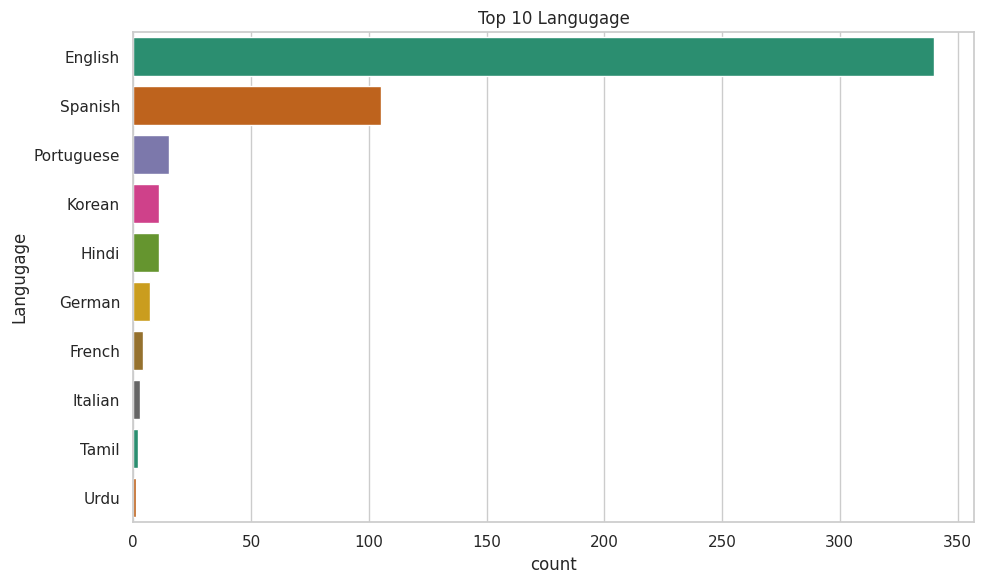

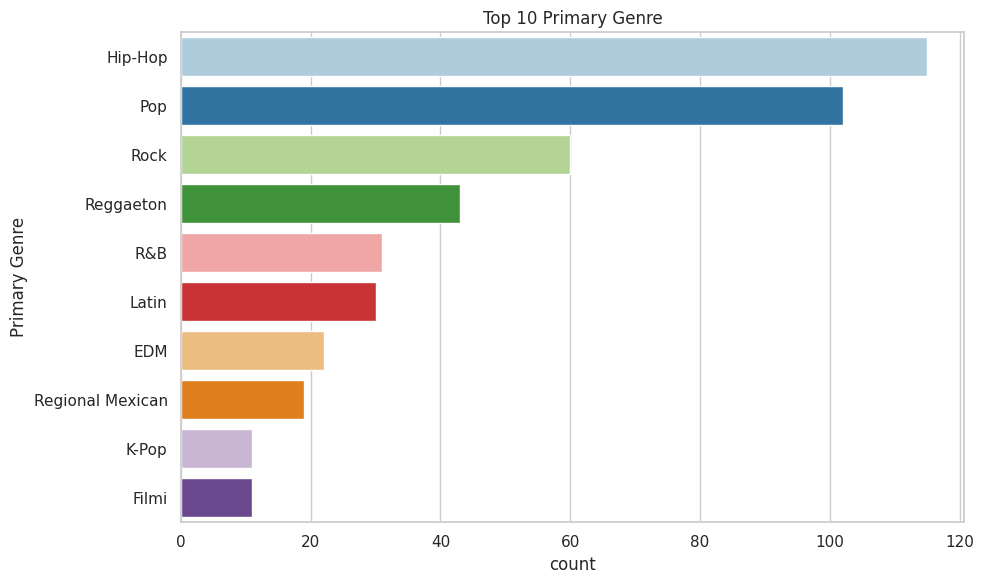

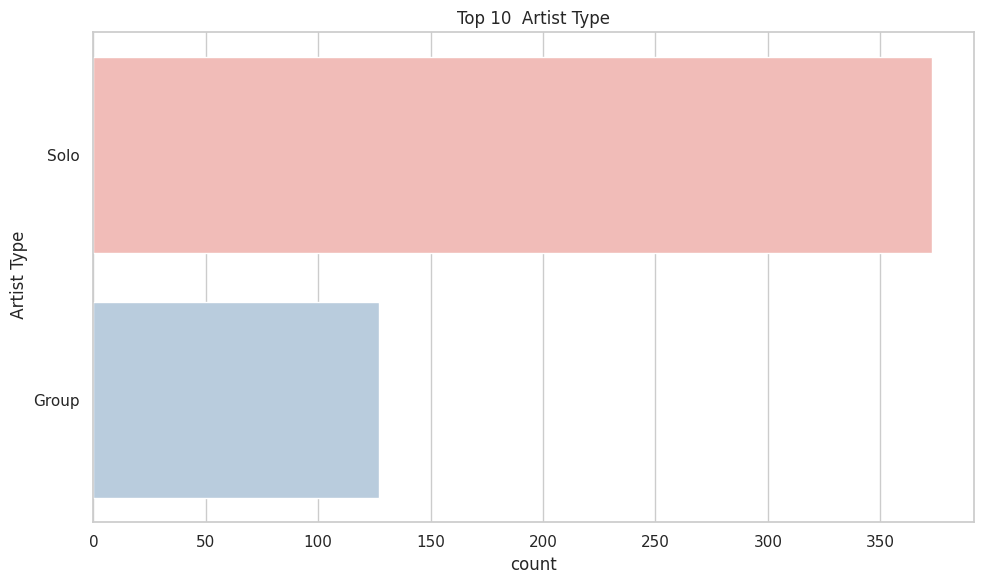

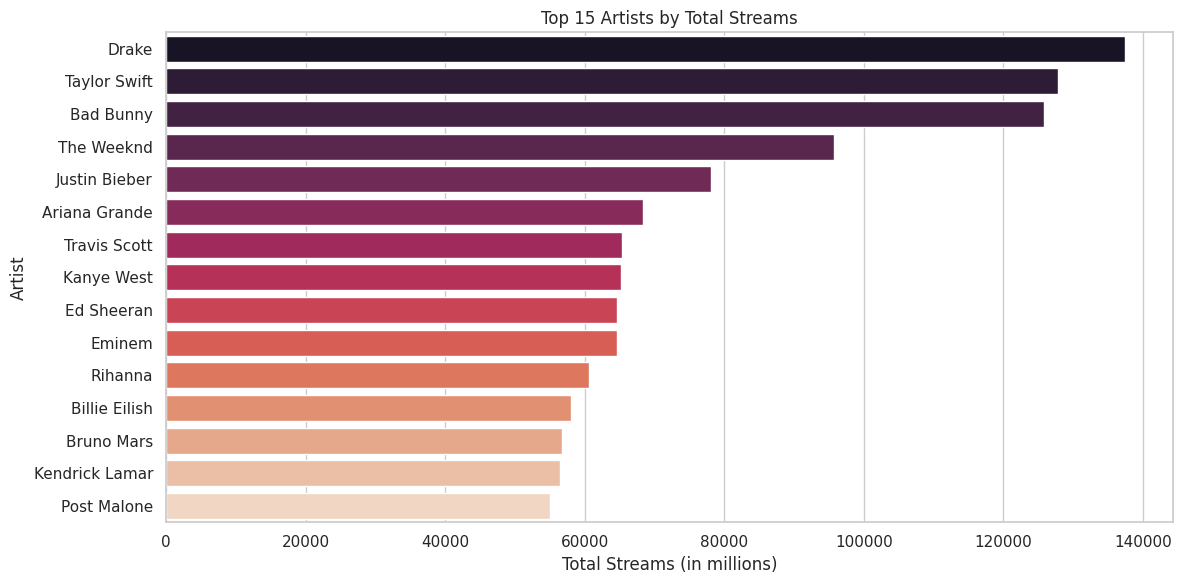

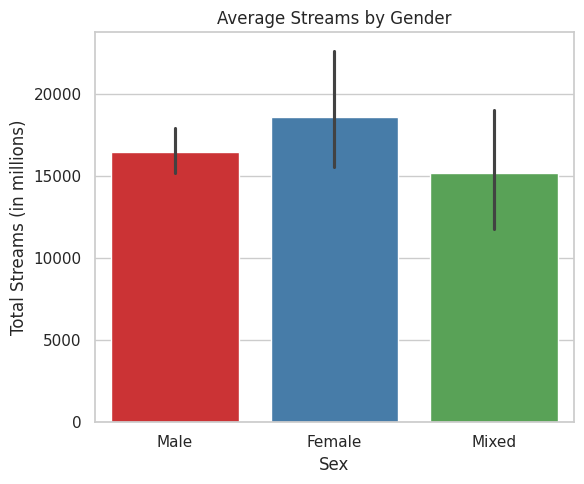

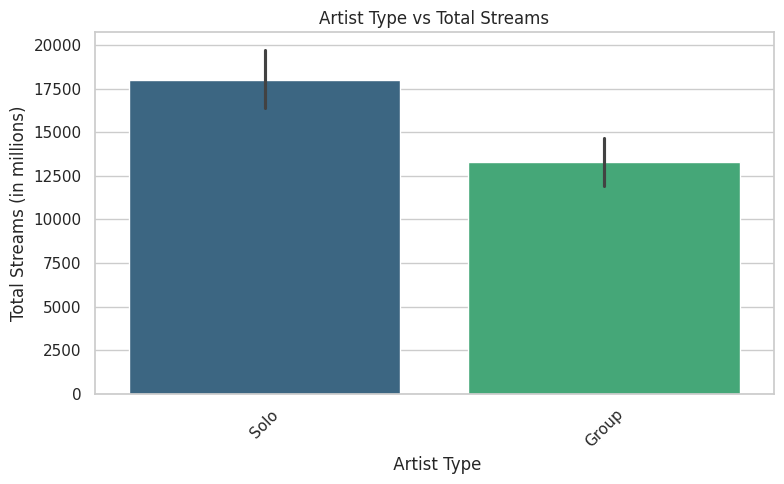

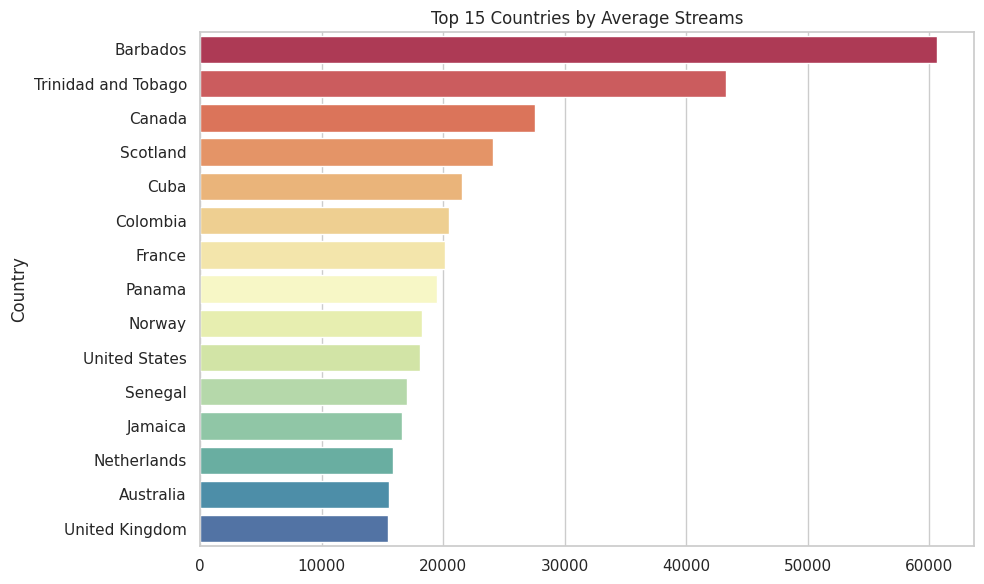

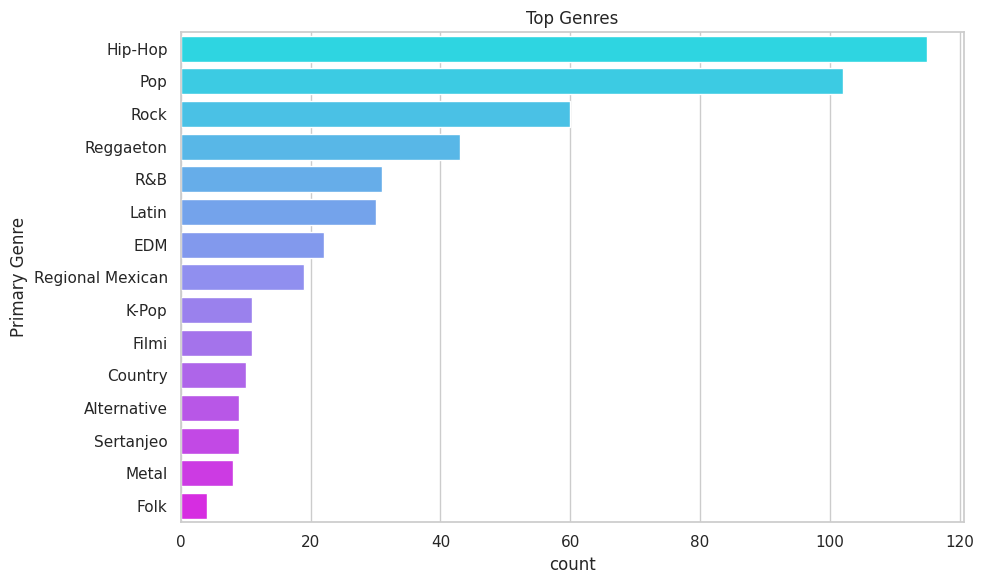

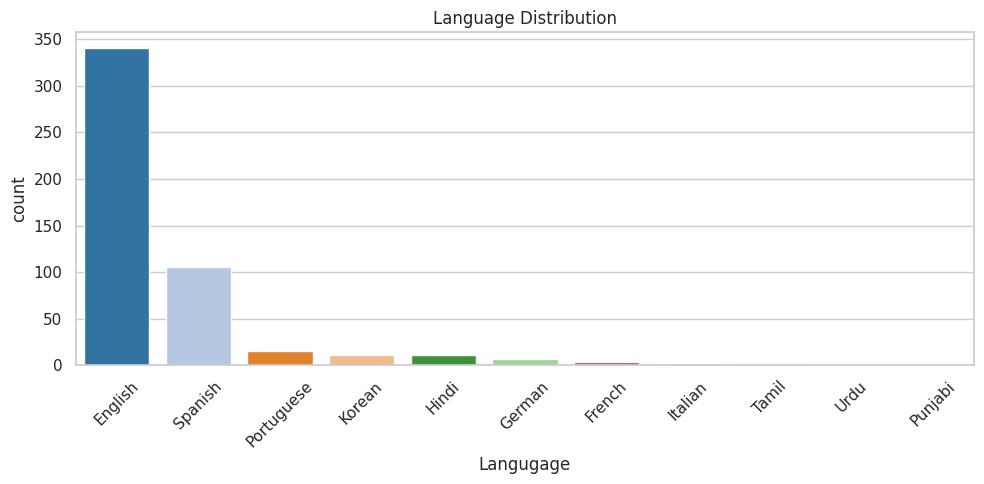

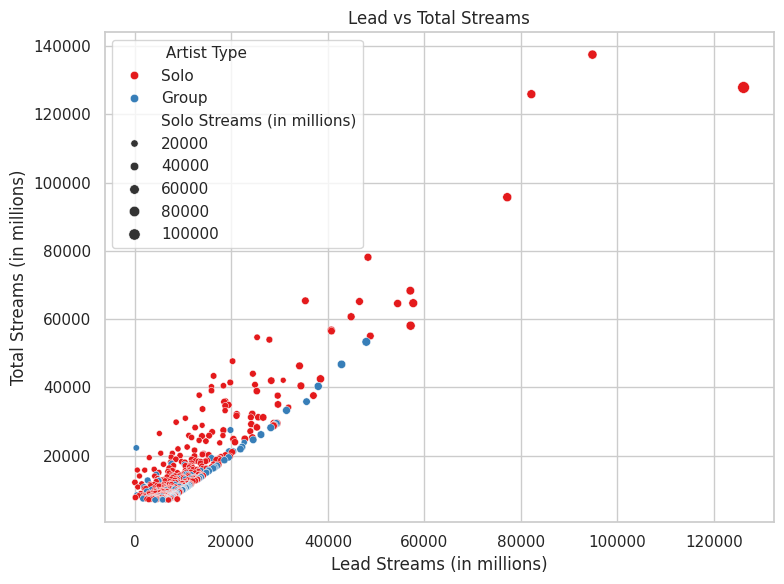

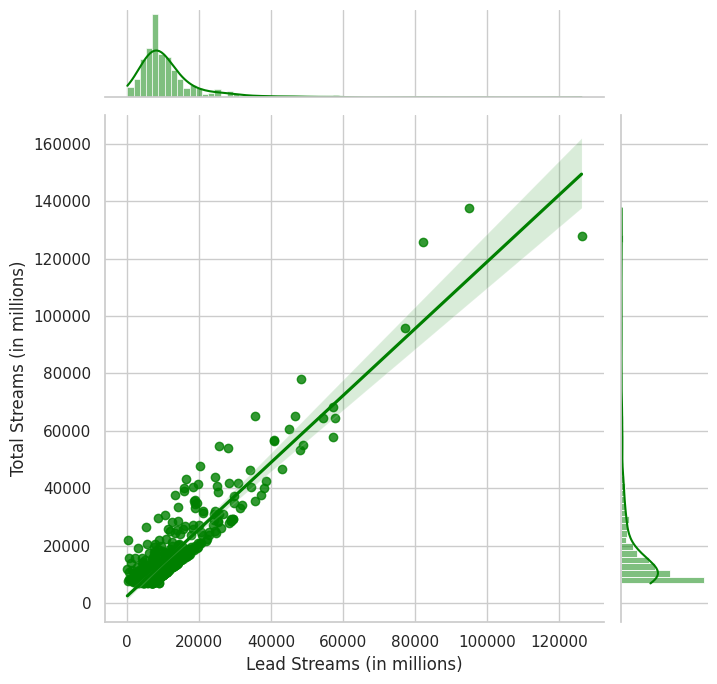

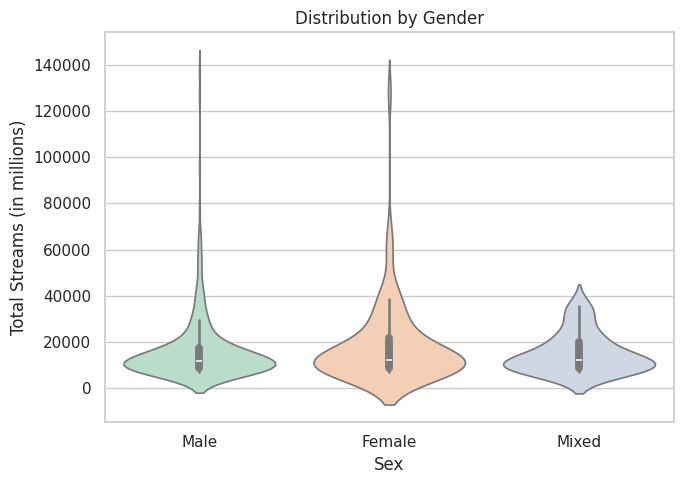

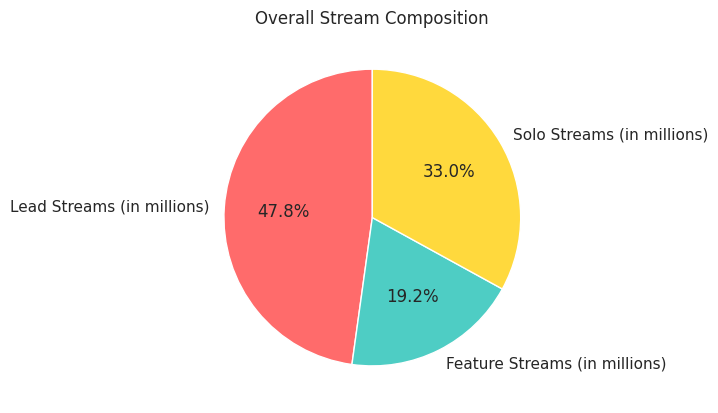

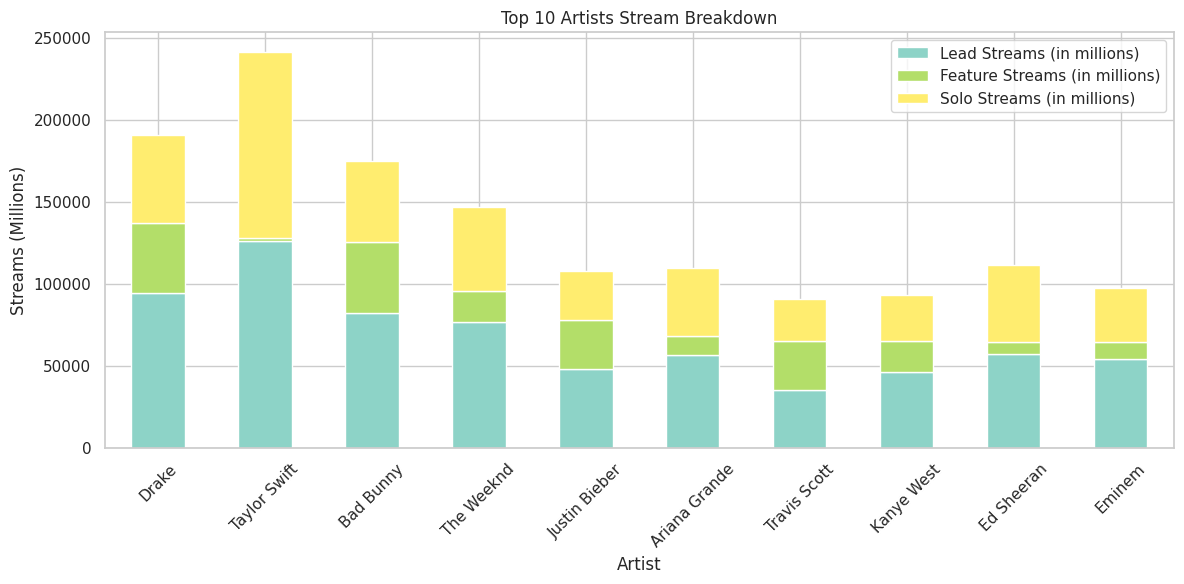

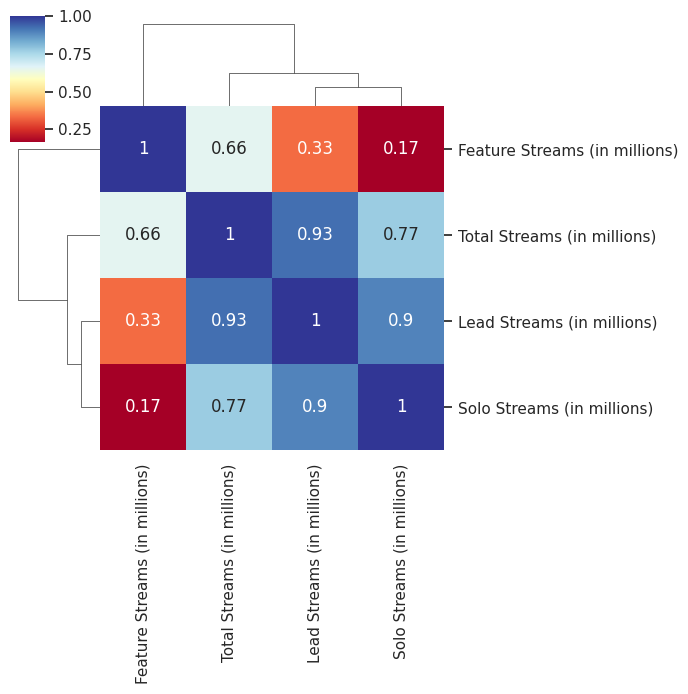

✅ Exploratory Data Analysis Completed Successfully!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# -----------------------------
# Styling
# -----------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

# -----------------------------
# Column Lists
# -----------------------------
num_cols = [
    'Total Streams (in millions)',
    'Lead Streams (in millions)',
    'Feature Streams (in millions)',
    'Solo Streams (in millions)'
]

cat_cols = [
    'Artist',
    'Sex',
    'Country',
    'Langugage',
    'Primary Genre',
    ' Artist Type'
]

# =============================
# 1. Histograms
# =============================
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True,
                 color=sns.color_palette("husl", len(num_cols))[num_cols.index(col)])
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# =============================
# 2. Boxplots
# =============================
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col],
                color=sns.color_palette("Set2", len(num_cols))[num_cols.index(col)])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# =============================
# 3. KDE Plots
# =============================
plt.figure(figsize=(10,6))
colors = sns.color_palette("Dark2", len(num_cols))

for col, color in zip(num_cols, colors):
    sns.kdeplot(df[col], fill=True, label=col, color=color)

plt.legend()
plt.title("Density Comparison of Stream Types")
plt.tight_layout()
plt.show()

# =============================
# 4. Correlation Heatmap
# =============================
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# =============================
# 5. Pairplot
# =============================
sns.pairplot(df[num_cols], corner=True)
plt.show()

# =============================
# 6. Countplots
# =============================
palettes = ["Set2","Set3","Accent","Dark2","Paired","Pastel1"]

for col, pal in zip(cat_cols, palettes):
    plt.figure(figsize=(10,6))
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10],
        palette=pal
    )
    plt.title(f"Top 10 {col}")
    plt.tight_layout()
    plt.show()

# =============================
# 7. Top 15 Artists
# =============================
top = df.sort_values(
    "Total Streams (in millions)",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x="Total Streams (in millions)",
    y="Artist",
    data=top,
    palette="rocket"
)
plt.title("Top 15 Artists by Total Streams")
plt.tight_layout()
plt.show()

# =============================
# 8. Average Streams by Gender
# =============================
plt.figure(figsize=(6,5))
sns.barplot(
    x="Sex",
    y="Total Streams (in millions)",
    data=df,
    estimator="mean",
    palette="Set1"
)
plt.title("Average Streams by Gender")
plt.tight_layout()
plt.show()

# =============================
# 9. Average Streams by Artist Type
# =============================
plt.figure(figsize=(8,5))
sns.barplot(
    x=" Artist Type",
    y="Total Streams (in millions)",
    data=df,
    estimator="mean",
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("Artist Type vs Total Streams")
plt.tight_layout()
plt.show()

# =============================
# 10. Country Wise Average Streams
# =============================
country = (
    df.groupby("Country")["Total Streams (in millions)"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=country.values,
    y=country.index,
    palette="Spectral"
)
plt.title("Top 15 Countries by Average Streams")
plt.tight_layout()
plt.show()

# =============================
# 11. Genre Distribution
# =============================
plt.figure(figsize=(10,6))
sns.countplot(
    y="Primary Genre",
    data=df,
    order=df["Primary Genre"].value_counts().index[:15],
    palette="cool"
)
plt.title("Top Genres")
plt.tight_layout()
plt.show()

# =============================
# 12. Language Distribution
# =============================
plt.figure(figsize=(10,5))
sns.countplot(
    x="Langugage",
    data=df,
    order=df["Langugage"].value_counts().index,
    palette="tab20"
)
plt.xticks(rotation=45)
plt.title("Language Distribution")
plt.tight_layout()
plt.show()

# =============================
# 13. Scatter Plot
# =============================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Lead Streams (in millions)",
    y="Total Streams (in millions)",
    hue=" Artist Type",
    size="Solo Streams (in millions)",
    data=df,
    palette="Set1"
)
plt.title("Lead vs Total Streams")
plt.tight_layout()
plt.show()

# =============================
# 14. Joint Plot
# =============================
sns.jointplot(
    x="Lead Streams (in millions)",
    y="Total Streams (in millions)",
    data=df,
    kind="reg",
    color="green",
    height=7
)
plt.show()

# =============================
# 15. Violin Plot
# =============================
plt.figure(figsize=(7,5))
sns.violinplot(
    x="Sex",
    y="Total Streams (in millions)",
    data=df,
    palette="Pastel2"
)
plt.title("Distribution by Gender")
plt.tight_layout()
plt.show()

# =============================
# 16. Pie Chart
# =============================
stream_sum = df[[
    "Lead Streams (in millions)",
    "Feature Streams (in millions)",
    "Solo Streams (in millions)"
]].sum()

plt.figure(figsize=(7,7))
plt.pie(
    stream_sum,
    labels=stream_sum.index,
    autopct="%1.1f%%",
    colors=["#FF6B6B","#4ECDC4","#FFD93D"],
    startangle=90
)
plt.title("Overall Stream Composition")
plt.tight_layout()
plt.show()

# =============================
# 17. Stacked Bar Chart
# =============================
top10 = df.nlargest(10, "Total Streams (in millions)")

top10.set_index("Artist")[[
    "Lead Streams (in millions)",
    "Feature Streams (in millions)",
    "Solo Streams (in millions)"
]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set3"
)

plt.title("Top 10 Artists Stream Breakdown")
plt.ylabel("Streams (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================
# 18. Clustermap
# =============================
sns.clustermap(
    df[num_cols].corr(),
    annot=True,
    cmap="RdYlBu",
    figsize=(7,7)
)
plt.show()

print("="*60)
print("✅ Exploratory Data Analysis Completed Successfully!")
print("="*60)

## Thanks.......Please Upvote